# 02f — Patrones de Diseño de Agentes

<figure>
<a
href="https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque2/02f-patrones-agentes.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

> Este tema forma parte del **Bloque 2 — Orquestación**. Se recomienda
> haber visto [02e — Diseño de Agentes Inteligentes](02e-agentes.qmd)
> primero, donde ya implementamos agentes ReAct con tool calling. Aquí
> damos un paso atrás: **¿qué arquitecturas existen para orquestar
> LLMs?** Esta taxonomía de patrones será la base del [proyecto
> integrador final](../evaluables/proyecto-final.qmd), donde elegirás un
> patrón (o propondrás uno propio) para resolver tu problema.

In [ ]:
!pip install -q langchain langchain-openai langchain-community python-dotenv

In [ ]:
"""
Setup compartido para la API key de Llamus en todos los notebooks.
Inyectado en cada .qmd/.ipynb vía scripts/sync_setup_keys.py (pre-render).

Orden de resolución:
  1. .env local (python-dotenv)
  2. os.environ ya configurado externamente
  3. Google Colab userdata: secret "LLAMUS_API_KEY" (preferente) o "LLM_API_KEY"

Las celdas posteriores pueden leer la key con os.environ.get("LLM_API_KEY").
"""

import os


def _load_llm_api_key():
    try:
        from dotenv import load_dotenv
        load_dotenv()
    except ImportError:
        pass

    if not os.getenv("LLM_API_KEY"):
        try:
            from google.colab import userdata
            for name in ("LLAMUS_API_KEY", "LLM_API_KEY"):
                try:
                    value = userdata.get(name)
                    if value:
                        os.environ["LLM_API_KEY"] = value
                        break
                except Exception:
                    continue
        except ImportError:
            pass


_load_llm_api_key()

if os.getenv("LLM_API_KEY"):
    print("✓ LLM_API_KEY cargada.")
else:
    print("⚠️  LLM_API_KEY no encontrada.")
    print("    • Local: crea un archivo .env con LLM_API_KEY=tu_clave")
    print("    • Colab: añade un Secret 🔑 con nombre 'LLAMUS_API_KEY'")


os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
print("Librerías cargadas correctamente.")

In [ ]:
from langchain_openai import ChatOpenAI

LLM_KEY = os.getenv("LLM_API_KEY")
LLM_URL = "https://llamus.cs.us.es/api/v1"

if not LLM_KEY:
    print("⚠️  Crea un archivo .env en la raíz del proyecto con:\n    LLM_API_KEY=tu_api_key\n    Las celdas siguientes mostrarán este mensaje hasta que configures la clave.")
else:
    llm = ChatOpenAI(model="mlx-community/Qwen3.6-35B-A3B-8bit", base_url=LLM_URL, api_key=LLM_KEY, temperature=0)
    print("✅ ChatOpenAI configurado. Las celdas de ejemplo funcionarán correctamente.")

## Patrones de diseño de agentes

Construir agentes efectivos requiere más que un buen modelo y un set de
herramientas: la **arquitectura** —cómo se orquesta el LLM, cómo se
descompone la tarea y cómo fluye el control— determina si un sistema es
fiable, depurable y rentable. Este tema presenta los patrones canónicos
que han surgido de despliegues de producción en Anthropic, OpenAI,
Google y la comunidad open source (Anthropic, 2024).

### Workflows vs. Agentes

> **Cuando usar agentes vs. workflows**
>
> - **Workflows**: flujo de control *predefinido*, con llamadas al LLM
>   en pasos concretos. Predecibles, testables, baratos. Úsalos cuando
>   la estructura de la tarea es conocida.
> - **Agentes**: el LLM *decide dinámicamente* qué hacer a continuación.
>   Flexibles, manejan situaciones nuevas. Úsalos cuando la tarea
>   requiere decisión adaptativa o exploración abierta.
>
> **Empieza con workflows.** Gradua a agentes solo cuando la tarea
> requiera genuinamente enrutamiento dinámico o exploración de final
> abierto.

La siguiente taxonomía —adaptada de la guía de Anthropic (Anthropic,
2024) y del capítulo “Agent Design Patterns” de Roitman (2026)—
distingue dos familias: patrones de **workflow** (el sistema decide el
orden) y patrones de **agente autónomo** (el LLM controla el flujo).

### Workflow patterns

Estos patrones usan LLMs dentro de un flujo de control *predefinido*. El
sistema (no el modelo) decide el orden de ejecución.

#### Prompt Chaining

El patrón más simple: dividir una tarea compleja en una **secuencia fija
de llamadas al LLM**, encadenando la salida de un paso como contexto del
siguiente. Entre pasos se pueden insertar **validaciones**
(programáticas o con LLM) que detectan errores pronto, antes de que se
propaguen.

<figure id="fig-prompt-chaining">
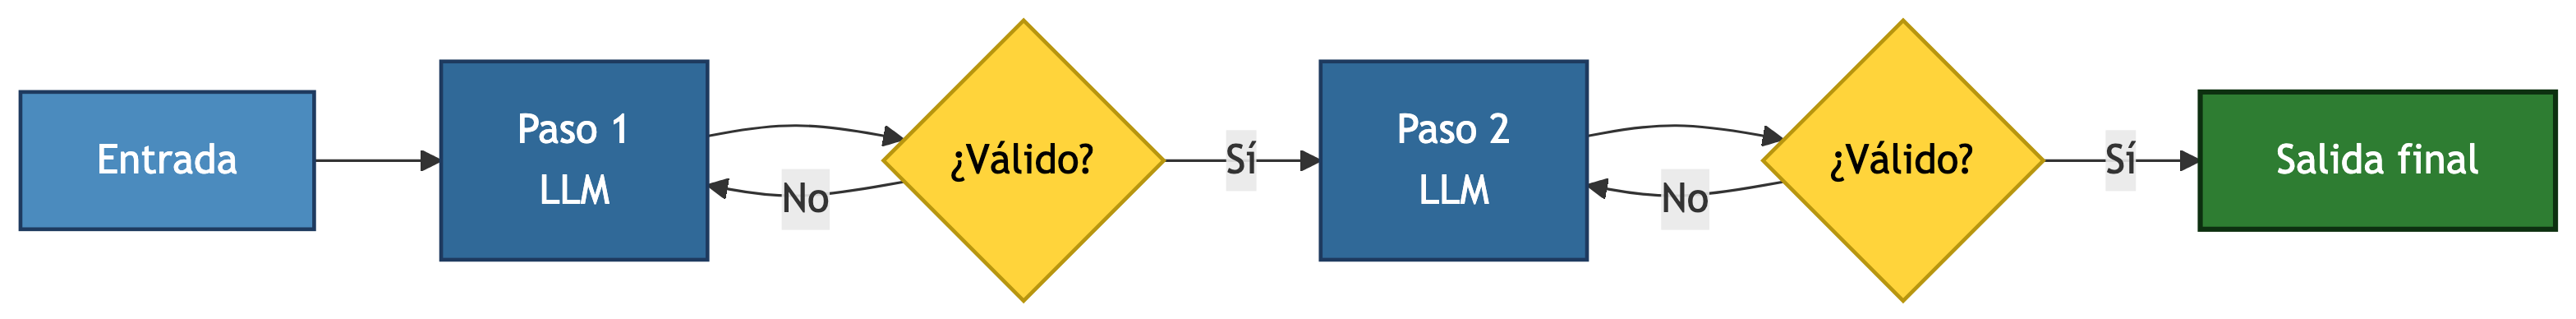
<figcaption>Figure 1</figcaption>
</figure>

**Cuándo usarlo**: tareas naturalmente secuenciales — generación de
contenido, transformación de datos, análisis multi-etapa.

**Ventaja clave**: cada paso puede usar un prompt, modelo o temperatura
distintos; los resultados intermedios son inspeccionables y depurables.

#### Routing

Un **clasificador** (LLM o tradicional) examina la entrada y la envía a
un **manejador especializado** (prompt, herramienta o modelo óptimo para
ese tipo de entrada).

<figure id="fig-routing">
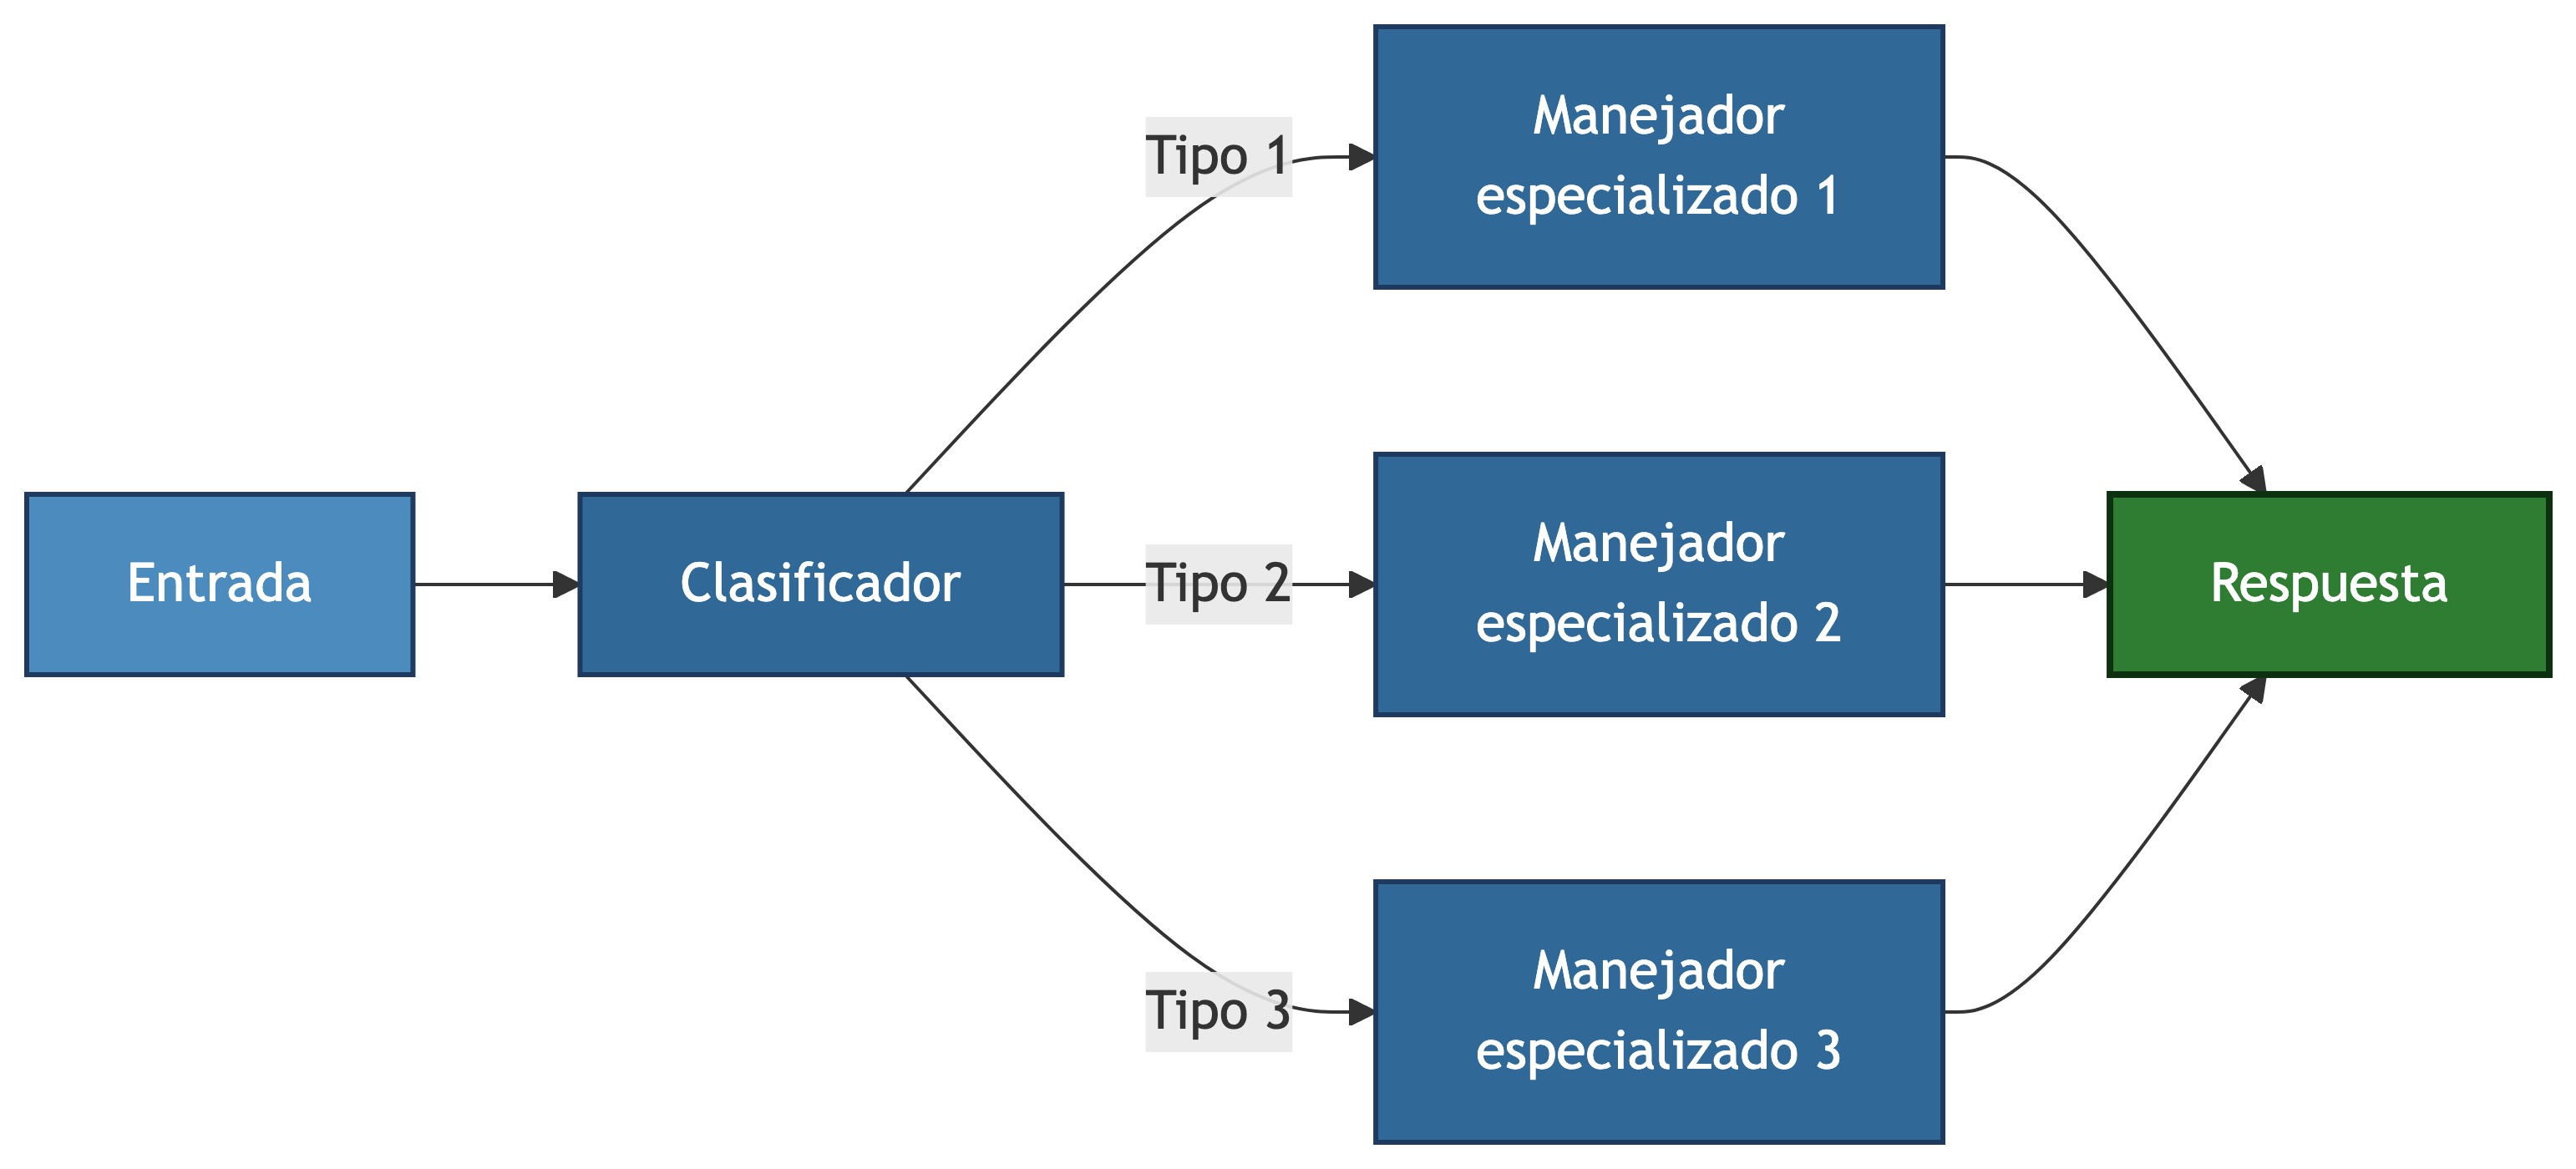
<figcaption>Figure 2</figcaption>
</figure>

**Cuándo usarlo**: tipos de tarea distintos con prompts, herramientas o
modelos óptimos diferentes — triaje de soporte, entrada multimodal,
preguntas factuales vs. analíticas.

#### Parallelization

Múltiples llamadas al LLM se ejecutan **en paralelo**, con una capa
programática que combina sus salidas. Dos sub-patrones:

- **Sectioning (fan-out)**: se particiona la entrada en trozos disjuntos
  y cada uno se procesa independientemente — p. ej. auditorías de
  seguridad, rendimiento y estilo sobre el mismo código.
- **Voting (redundancia)**: se lanza el mismo prompt N veces con seeds o
  temperaturas distintas y se selecciona el mejor resultado por mayoría,
  score de reward model o LLM-as-judge (X. Wang et al., 2023).

<figure id="fig-parallelization">
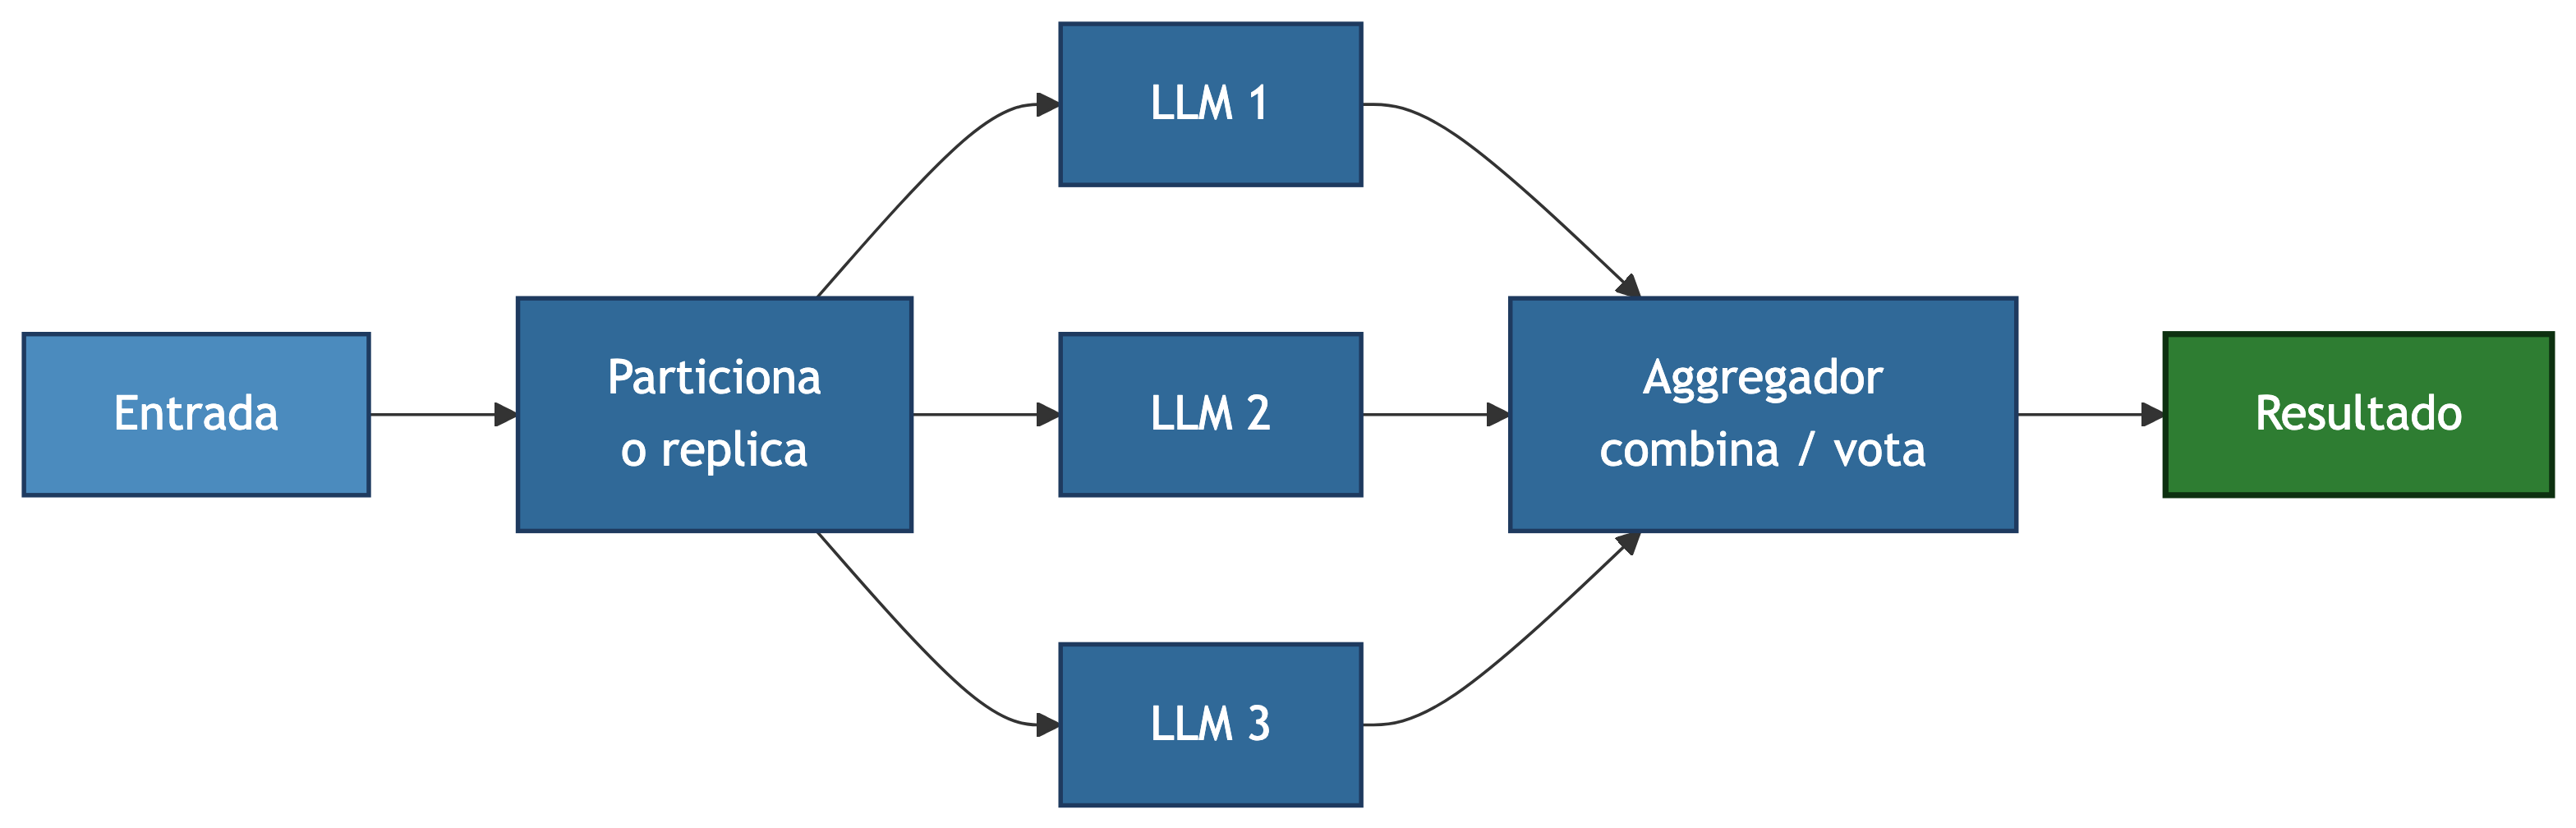
<figcaption>Figure 3</figcaption>
</figure>

La latencia resultante es $\max$ de las llamadas individuales, no su
suma.

#### Orchestrator-Workers

Aquí el **LLM decide cómo dividir el trabajo**: un orquestador analiza
la tarea, produce un plan de subtareas, las despacha a workers
(posiblemente con prompts o herramientas distintas) y finalmente
**fusiona sus salidas** en un resultado coherente. La diferencia clave
con parallelization: la descomposición es generada por el modelo, no
hardcodeada.

<figure id="fig-orchestrator-workers">
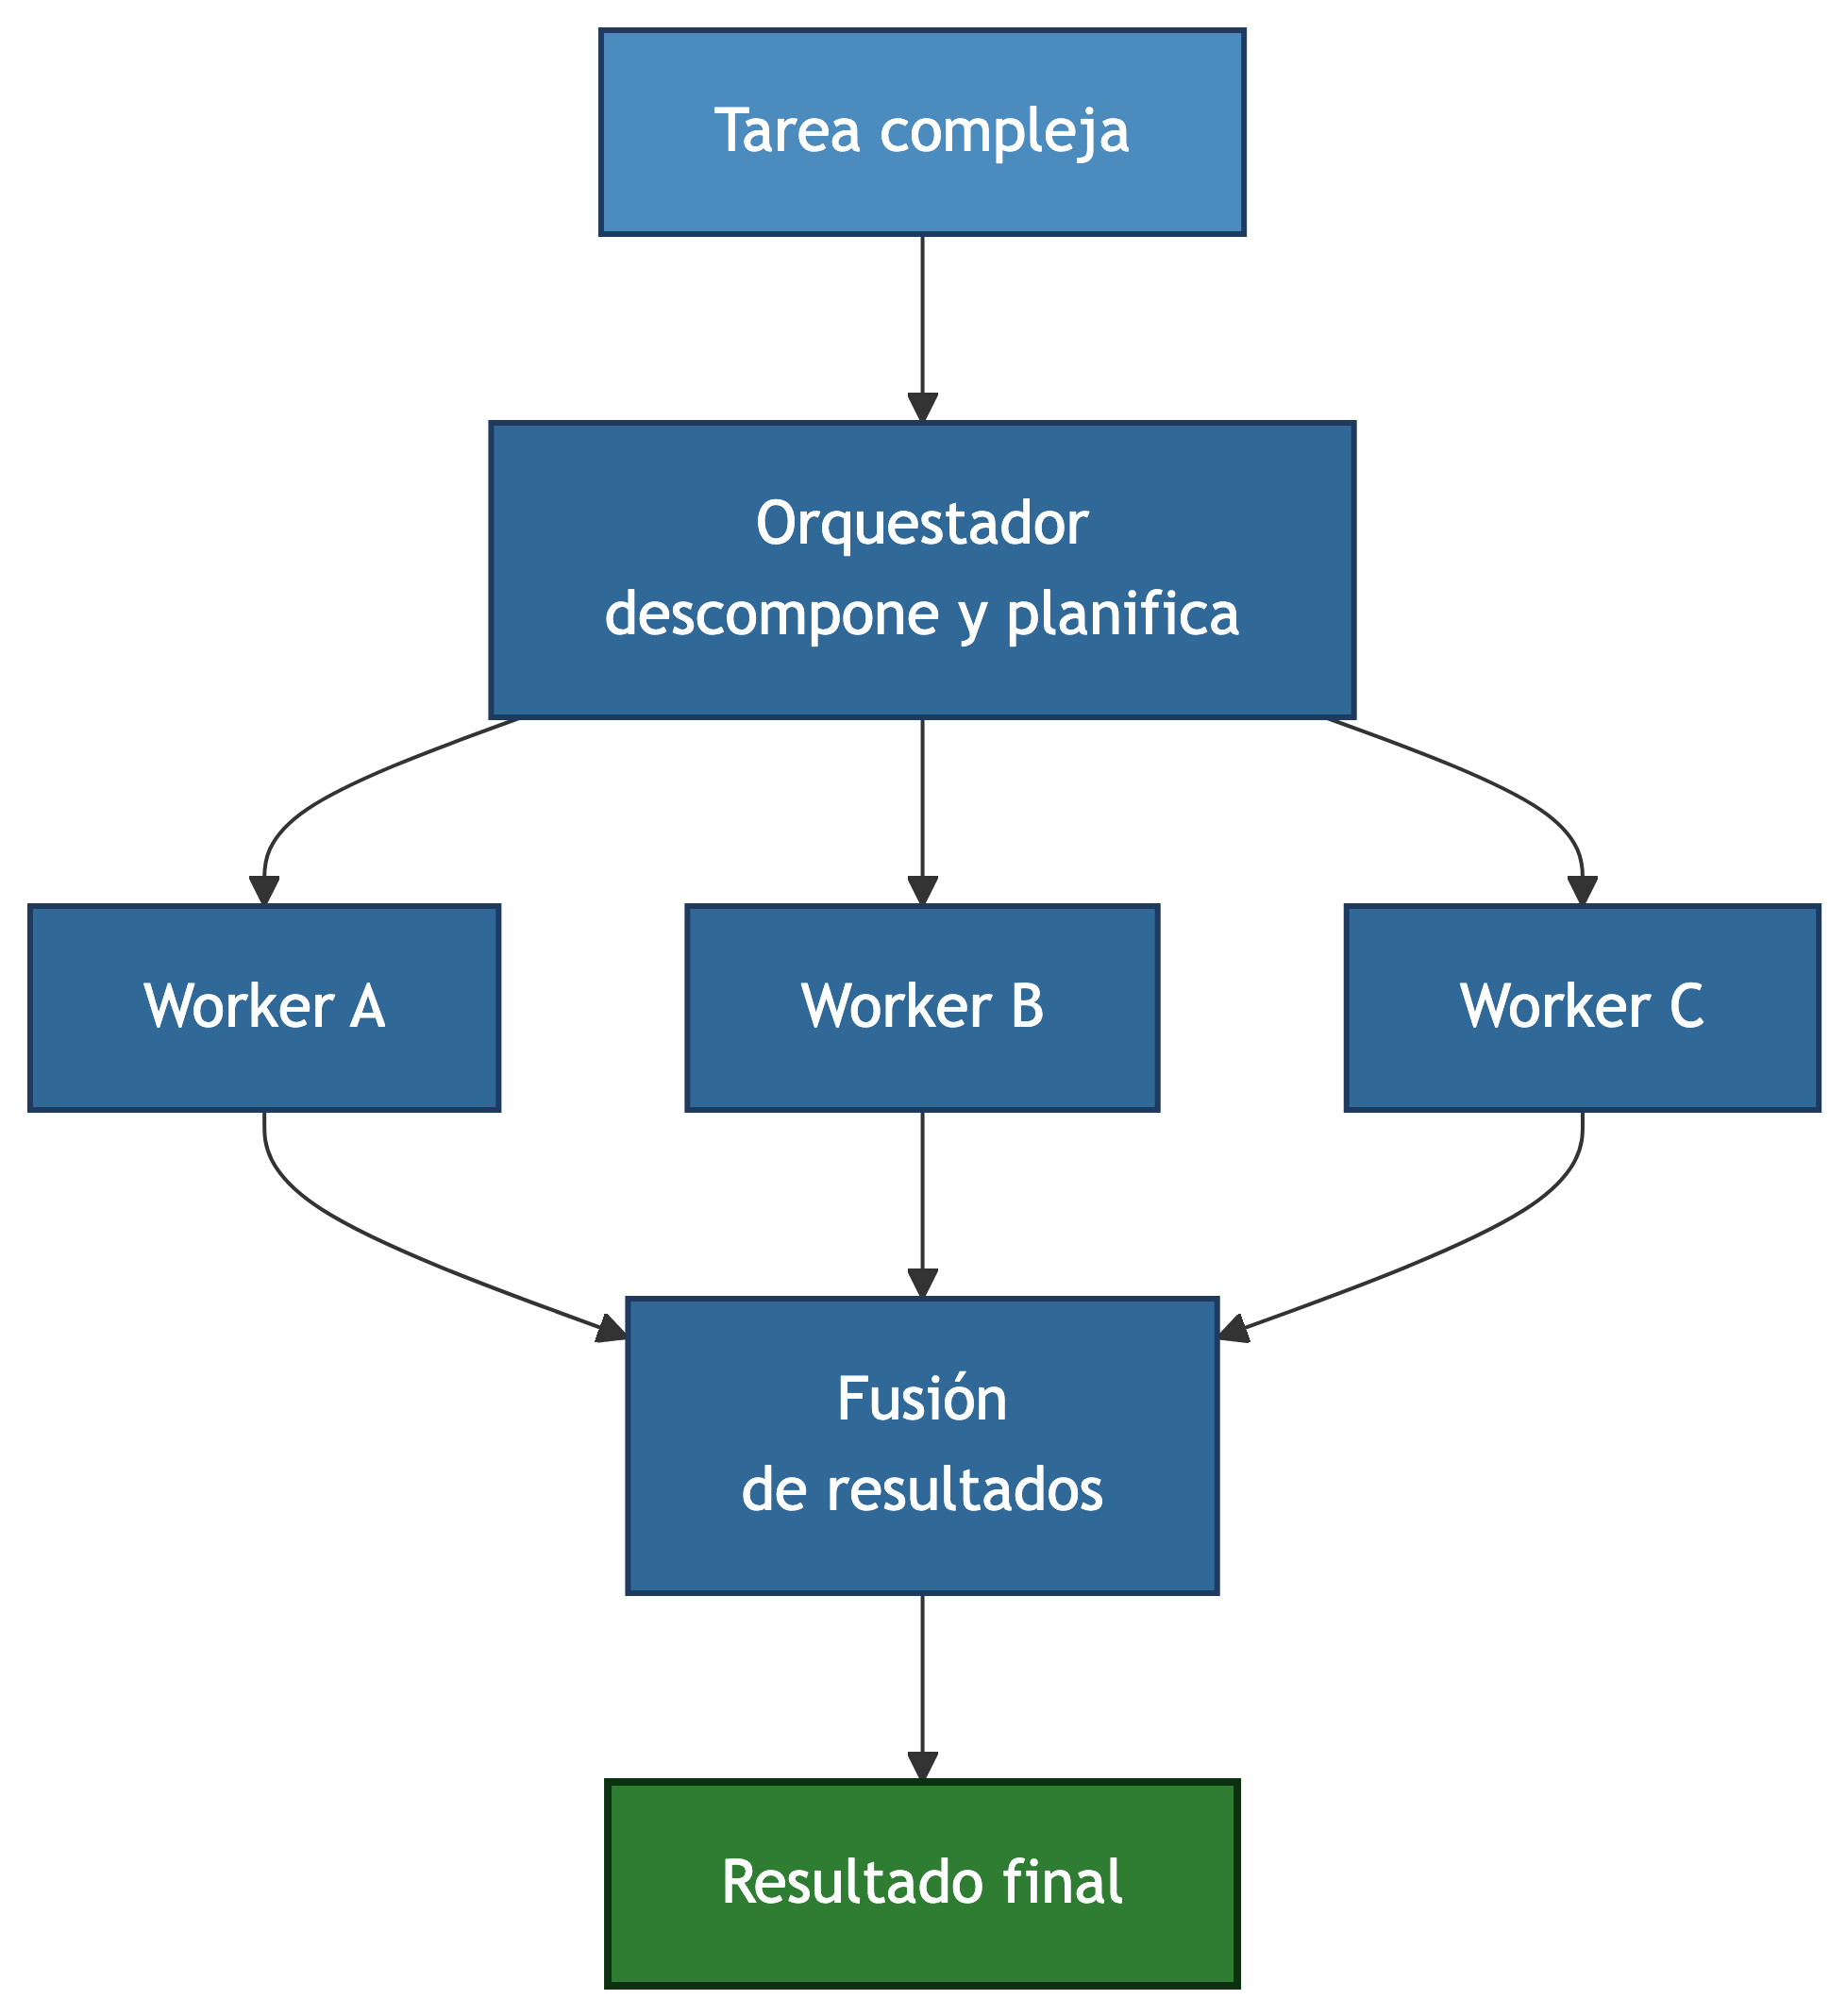
<figcaption>Figure 4</figcaption>
</figure>

**Cuándo usarlo**: problemas abiertos donde el número y naturaleza de
subtareas no puede enumerarse en diseño — p. ej. “refactoriza este
codebase” requiere primero entender el grafo de dependencias antes de
decidir qué archivos modificar.

#### Evaluator-Optimizer

Un **bucle de retroalimentación de dos modelos**: un generador produce
candidatos mientras un evaluador separado los puntúa contra criterios
explícitos. Si el score no alcanza el umbral, la crítica del evaluador
se añade al contexto del generador y el ciclo se repite hasta cumplir la
barra de calidad o agotar un presupuesto de reintentos
(<span class="nocase">Madaan et al.</span>, 2023).

<figure id="fig-evaluator-optimizer">
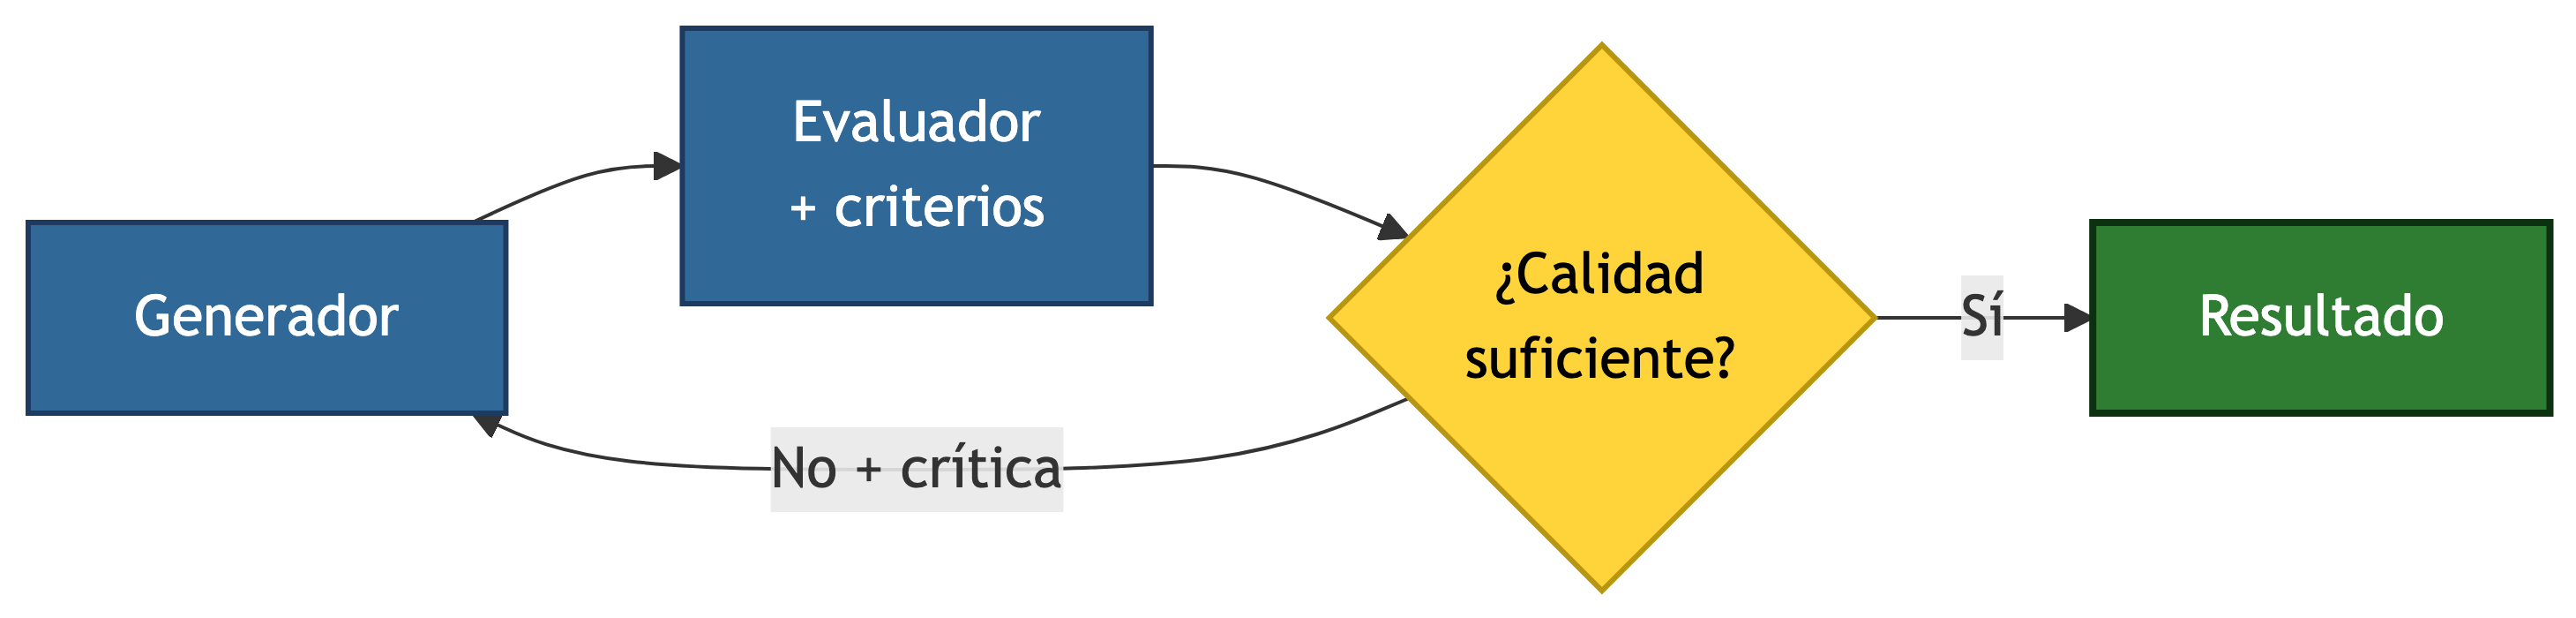
<figcaption>Figure 5</figcaption>
</figure>

**Cuándo usarlo**: tareas con criterios de calidad claros — código que
debe pasar tests, traducciones que deben preservar significado,
escritura que debe ajustarse a una guía de estilo.

### Patrones de agente autónomo

Estos patrones ceden al LLM el control del flujo de ejecución.

#### ReAct (Reasoning + Acting)

El patrón fundacional (Yao et al., 2023), ya implementado en [02e —
Agentes](02e-agentes.qmd#sec-react). El LLM alterna razonamiento
(Thought), acción (Action) y observación (Observation) en un bucle hasta
producir la respuesta final. Es la base de `create_agent` en LangChain y
del HPD 2.

#### Planning: Plan-and-Execute

En lugar de decidir un paso cada vez, el agente genera primero un **plan
completo** y luego lo ejecuta (L. Wang et al., 2023):

1.  **Fase de planificación**: dado el objetivo, generar un plan
    estructurado (lista de subtareas con dependencias).
2.  **Fase de ejecución**: ejecutar cada subtarea, posiblemente con un
    modelo más barato.
3.  **Revisión del plan**: si un paso falla o produce resultados
    inesperados, re-planificar desde el estado actual.

El plan es un **documento vivo**: da estructura pero se adapta a las
observaciones. Cuatro estrategias de replanning:

| Estrategia | ¿Cuándo re-planifica? | Características |
|------------------------|------------------------|------------------------|
| Plan-then-Execute | Nunca | Simple; frágil ante resultados inesperados |
| Adaptativa | Al fallar un paso | Solo cuando un paso falla; coste moderado |
| Continua | En cada paso | Reevaluación completa tras cada observación; cara pero robusta |
| Jerárquica | Al terminar un sub-plan | Plan de alto nivel fijo; sub-planes dinámicos |

Table 1: Estrategias de replanning en agentes de planificación

**Cuándo usarlo**: tareas de horizonte largo con muchos pasos. Más
eficiente que ReAct para ese tipo de tareas (menos llamadas al LLM),
pero menos adaptativo a observaciones inesperadas.

#### Reflection y Reflexion

El agente se **pausa para evaluar su propia trayectoria** y corregir el
rumbo:

1.  **Validación de salida**: “¿es correcto esto? ¿me he dejado algo?”
2.  **Revisión de trayectoria**: revisar los últimos k pasos e
    identificar errores o ineficiencias.
3.  **Revisión de estrategia**: reconsiderar el enfoque global (“¿estoy
    resolviendo el problema correcto?”).

> **Reflexion: aprender del fracaso**
>
> El patrón **Reflexion** (Shinn et al., 2023) mantiene una “memoria de
> reflexión” persistente: tras cada intento fallido, el agente escribe
> una reflexión en lenguaje natural (“fallé porque no comprobé el caso
> límite”). En el siguiente intento, estas reflexiones se incluyen en el
> prompt — aprendizaje entre episodios **sin actualizar pesos**.

#### Tool-use patterns

Cómo invoca el agente sus herramientas afecta a fiabilidad, latencia y
coste. Cinco patrones canónicos (<span class="nocase">Schick et
al.</span>, 2023):

| Patrón | Descripción | Ejemplo |
|------------------------|------------------------|------------------------|
| Single-turn | Una llamada a tool por respuesta | Q&A simple con búsqueda |
| Multi-tool | Varias llamadas en paralelo en una respuesta | Buscar + calcular + formatear |
| Sequential | La salida de una tool alimenta la siguiente | Buscar → leer → extraer |
| Nested | Una tool invoca a otro agente | Agente de código llama a test-runner |
| Fallback | Si la tool preferida falla, probar alternativa | API → scrape → caché |

Table 2: Patrones de invocación de herramientas

El **nested (agent-as-tool)** merece atención: una herramienta invoca a
un agente completamente separado, con su propio prompt, tools y
contexto. El agente padre trata al sub-agente como una caja negra. El
patrón Swarm (OpenAI, 2024) lo generaliza mediante **handoffs** entre
agentes especializados.

### Human-in-the-loop

Los agentes de producción deben saber **cuándo pausar y pedir
intervención humana**:

- **Gates de aprobación**: antes de acciones irreversibles (enviar
  emails, borrar archivos, comprar), requerir confirmación humana
  explícita.
- **Criterios de escalado**: escalar cuando la confianza es baja, la
  tarea está fuera de alcance o se dispara una regla de seguridad.
- **Integración de feedback**: las correcciones humanas se insertan en
  el contexto y pueden actualizar el plan del agente.
- **Aprobación asíncrona**: en tareas largas, el agente pausa, notifica
  (email/Slack) y reanuda al aprobarse.

Este patrón conecta directamente con la gobernanza del [Bloque
4](../bloque4/04-gobernanza.qmd).

### Workflow graphs

Para workflows complejos, la lógica de orquestación se expresa como un
**grafo dirigido acíclico (DAG)** o máquina de estados:

- **LangGraph** (LangChain, 2024): extiende LangChain con ejecución
  basada en grafos. Los nodos son pasos del agente; las aristas,
  transiciones condicionales. Soporta ciclos (para bucles ReAct) y ramas
  paralelas. Ya lo usamos en [02e](02e-agentes.qmd#sec-rag-langgraph)
  para el pipeline RAG supervisado.
- **AutoGen** (<span class="nocase">Wu et al.</span>, 2023): framework
  de Microsoft para grafos de conversación multi-agente: nested chats,
  group chats y human-in-the-loop.
- **Máquinas de estado**: estados explícitos (`PLANNING`, `EXECUTING`,
  `WAITING_FOR_HUMAN`, `DONE`) con transiciones definidas. Más fáciles
  de razonar y testear que bucles implícitos.

### Principios de diseño

Los siguientes principios, destilados de la guía de Anthropic
(Anthropic, 2024), aplican a todos los patrones:

1.  **Manténlo simple.** Usa la arquitectura más simple que funcione.
    Añade complejidad solo cuando se demuestre necesaria. Una cadena de
    prompts que resuelve el problema es siempre preferible a un sistema
    multi-agente que *podría* resolverlo.
2.  **Transparencia sobre ingenio.** Cada paso debe ser inspeccionable.
    Evita estado oculto o razonamiento implícito: cuando un agente
    falla, necesitas entender *por qué*.
3.  **Proporciona buenas herramientas.** Herramientas bien documentadas,
    bien tipadas y con mensajes de error claros son multiplicadores de
    fuerza.
4.  **Planifica para el fallo.** Toda llamada a tool puede fallar.
    Construye reintentos, fallbacks y degradación elegante a nivel del
    harness, para que el modelo no tenga que razonar sobre fallos de
    infraestructura.
5.  **Usa salidas estructuradas.** La generación restringida (JSON
    schema, function calling) evita fallos de parseo.
6.  **Testea con entradas diversas.** El comportamiento del agente es
    más variable que el chat de un solo turno: el mismo prompt puede
    producir secuencias de tool calls distintas en ejecuciones
    diferentes.

### Guía de selección de patrones

Elegir el patrón correcto depende de tres factores: (1) lo predecible
que es la estructura de la tarea, (2) cuántas llamadas al LLM puedes
permitirte en latencia y coste, y (3) si la calidad requiere iteración.
Usa esta matriz como punto de partida — empieza por arriba (lo más
simple) y baja solo cuando el patrón simple falle demostrablemente:

| Patrón | Complejidad | Llamadas LLM | Mejor para |
|------------------|------------------|------------------|------------------|
| Prompt chaining | Baja | N (fijas) | Tareas secuenciales, pipelines de contenido |
| Routing | Baja | 1 + 1 | Entradas multi-tipo, triaje |
| Parallelization | Baja | N (paralelas) | Subtareas independientes, votación |
| Orchestrator-workers | Media | Variable | Descomposición desconocida |
| Evaluator-optimizer | Media | 2-10 (bucle) | Salidas críticas en calidad |
| ReAct | Media | 3-25 (bucle) | Uso general de tools, exploración |
| Planning | Alta | 5-50+ | Tareas de horizonte largo |
| Reflection | Alta | +50 % overhead | Tareas donde el primer intento suele fallar |
| Multi-agente | Alta | Muchas | Dominios complejos, especialización |

Table 3: Cuándo usar cada patrón de diseño

> **Los patrones se componen**
>
> Un agente de planificación puede usar prompt chaining para pasos
> individuales, un evaluator-optimizer dentro de su fase de revisión y
> routing para despachar subtareas a especialistas. El arte está en
> saber **cuándo dejar de añadir capas**.

## Ejemplos prácticos

Veamos dos patrones de workflow en código: **prompt chaining** y
**routing** con LangChain.

### Prompt chaining con LCEL

Doble llamada: primero un borrador, luego una revisión que lo mejora. El
resultado del primer paso es el contexto del segundo.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Paso 1: generar el borrador
paso1 = ChatPromptTemplate.from_messages([
    ("system", "Eres un redactor técnico. Escribe un resumen ejecutivo del texto dado."),
    ("user", "{texto}")
]) | llm | StrOutputParser()

# Paso 2: revisar el borrador
paso2 = ChatPromptTemplate.from_messages([
    ("system", "Eres un editor senior. Mejora el borrador: corrige imprecisiones, "
               "hazlo más conciso y añade una conclusión con recomendaciones."),
    ("user", "Borrador:\n{borrador}")
]) | llm | StrOutputParser()

cadena = paso1 | paso2  # LCEL: la salida del paso 1 alimenta al paso 2

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ejecutar el ejemplo.")
else:
    texto = "La empresa tiene 120 empleados, creció un 15% este año y planea expandirse a LATAM en 2026."
    print("=== Paso 1: borrador ===")
    print(paso1.invoke({"texto": texto})[:200], "...")
    print("\n=== Paso 2: versión final ===")
    print(cadena.invoke({"texto": texto}))

Si el borrador no supera una validación (p. ej. longitud mínima), un
paso programático puede reenviarlo al generador antes de pasar al
siguiente — ese es el *gate* del patrón.

### Routing con LangChain

Un clasificador decide qué prompt especializado recibe cada pregunta:

In [ ]:
# Dos manejadores especializados
prompt_facto = ChatPromptTemplate.from_messages([
    ("system", "Responde con datos concretos y precisos. Si no los sabes, dilo."),
    ("user", "{pregunta}")
]) | llm | StrOutputParser()

prompt_analisis = ChatPromptTemplate.from_messages([
    ("system", "Da una respuesta analítica: causas, tendencias y recomendaciones."),
    ("user", "{pregunta}")
]) | llm | StrOutputParser()

def clasificar(pregunta: str) -> str:
    """El propio LLM decide la ruta: 'factual' o 'analitica'."""
    resp = llm.invoke(
        f"Clasifica la pregunta como 'factual' (pide datos concretos) "
        f"o 'analitica' (pide interpretación). Pregunta: {pregunta}\n"
        "Responde solo con una palabra: factual o analitica"
    )
    ruta = resp.content.strip().lower()
    return "factual" if ruta.startswith("fact") else "analitica"

def router(pregunta: str) -> str:
    if clasificar(pregunta) == "factual":
        return prompt_facto.invoke({"pregunta": pregunta})
    return prompt_analisis.invoke({"pregunta": pregunta})

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ejecutar el ejemplo.")
else:
    for p in ["¿Cuál es la población de Sevilla?", "¿Por qué crees que bajaron las ventas?"]:
        print(f"\nPREGUNTA: {p}")
        print(f"→ Ruta: {clasificar(p)}")
        print(f"→ Respuesta: {router(p)}")

Fíjate en que el routing suele costar solo **1 llamada extra** (la
clasificación) y evita que un prompt genérico degrade las respuestas
especializadas — por eso aparece como complejidad “baja” en
<a href="#tbl-guia-seleccion" class="quarto-xref">Table 3</a>.

## Lecturas recomendadas

- Anthropic (2024) — la guía original de la que parte esta taxonomía
- Yao et al. (2023) — el patrón ReAct (profundizado en 02e)
- L. Wang et al. (2023) — Plan-and-Solve prompting
- Shinn et al. (2023) — Reflexion: aprendizaje verbal entre episodios
- <span class="nocase">Madaan et al.</span> (2023) — Self-Refine:
  iteración con auto-feedback
- <span class="nocase">Schick et al.</span> (2023) — Toolformer: enseñar
  a los LLMs a usar herramientas
- X. Wang et al. (2023) — self-consistency para votación paralela
- LangChain (2024) — LangGraph, grafos de ejecución para agentes

# References

Anthropic. (2024). *Building effective agents*. Blog técnico.
<https://www.anthropic.com/research/building-effective-agents>

LangChain. (2024). *LangGraph: Build stateful multi-actor applications
with LLMs*. Repositorio GitHub.
<https://github.com/langchain-ai/langgraph>

<span class="nocase">Madaan, A., Tandon, N., Gupta, P., et al.</span>
(2023). Self-refine: Iterative refinement with self-feedback. *Advances
in Neural Information Processing Systems (NeurIPS)*.
<https://arxiv.org/abs/2303.17651>

OpenAI. (2024). *Swarm: An educational framework for lightweight
multi-agent orchestration*. Repositorio GitHub.
<https://github.com/openai/swarm>

Roitman, H. (2026). *The hitchhiker’s guide to agentic AI: From
foundations to systems*. Versión 1.2.2. Licencia CC BY-SA 4.0.
<https://creativecommons.org/licenses/by-sa/4.0/>

<span class="nocase">Schick, T., Dwivedi-Yu, J., Dessì, R., et
al.</span> (2023). Toolformer: Language models can teach themselves to
use tools. *Advances in Neural Information Processing Systems
(NeurIPS)*. <https://arxiv.org/abs/2302.04761>

Shinn, N., Cassano, F., Gopinath, A., Narasimhan, K., & Yao, S. (2023).
Reflexion: Language agents with verbal reinforcement learning. *Advances
in Neural Information Processing Systems (NeurIPS)*.
<https://arxiv.org/abs/2303.11366>

Wang, L., Xu, W., Lan, Y., Hu, Z., Lan, Y., Lee, R. K.-W., & Lim, E.-P.
(2023). Plan-and-solve prompting: Improving zero-shot chain-of-thought
reasoning by large language models. *Proceedings of the 61st Annual
Meeting of the Association for Computational Linguistics (ACL)*.
<https://arxiv.org/abs/2305.04091>

Wang, X., Wei, J., Schuurmans, D., Le, Q. V., Chi, E. H., Narang, S.,
Chowdhery, A., & Zhou, D. (2023). Self-consistency improves chain of
thought reasoning in language models. *International Conference on
Learning Representations (ICLR)*. <https://arxiv.org/abs/2203.11171>

<span class="nocase">Wu, Q., Bansal, G., Zhang, J., et al.</span>
(2023). AutoGen: Enabling next-gen LLM applications via multi-agent
conversation. *arXiv Preprint arXiv:2308.08155*.
<https://arxiv.org/abs/2308.08155>

Yao, S., Zhao, J., Yu, D., Du, N., Shafran, I., Narasimhan, K. R., &
Cao, Y. (2023). ReAct: Synergizing reasoning and acting in language
models. *International Conference on Learning Representations (ICLR)*.
<https://arxiv.org/abs/2210.03629>